In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


## import libraries

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split,DataLoader,TensorDataset

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

## Reading files

In [3]:
train=pd.read_csv("../input/digit-recognizer/train.csv")
test=pd.read_csv("../input/digit-recognizer/test.csv")

In [4]:
test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
len(train)

42000

In [7]:
len(test)

28000

In [8]:
train.shape

(42000, 785)

In [9]:
test.shape

(28000, 784)

In [10]:
# Target variable
labels=train.label

In [11]:
# Independent variables
train_ds=train.drop('label',axis=1)

In [12]:
train_ds.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


0


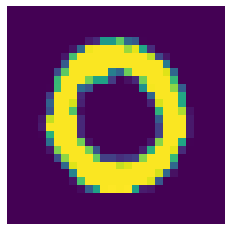

In [13]:
plt.imshow(train_ds[1:2].values.reshape(28,28))
plt.axis("off")
print(labels[1])

## converting the data to numpy arrays

In [14]:
train_ds=train_ds.values
test_ds=test.values
labels=labels.to_numpy()             #labels was actually a pandas series

## convert data to tensor

In [15]:
train_ds=torch.tensor(train_ds)
test_ds =torch.tensor(test_ds)
labels = torch.tensor(labels)

## converting data into tensordataset

In [16]:
traiin_ds=TensorDataset(train_ds,labels)

In [17]:
traiin_ds[0:2]

(tensor([[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]),
 tensor([1, 0]))

## Define training and validation data

In [18]:
train_ds , val_ds = random_split(traiin_ds,(32000,10000))

In [19]:
train_loader=DataLoader(train_ds , batch_size=128, shuffle = True)
val_loader=DataLoader(val_ds , batch_size=128, shuffle = False)

In [20]:
test_loader=DataLoader(test_ds , batch_size=128, shuffle = False)

In [21]:
# for each image
input_size = 784
num_class = 10

## Cnn Model

In [22]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
                                                                        
        self.conv1 = nn.Conv2d(
                                in_channels=1,
                                out_channels=8,
                                kernel_size=(3, 3),
                                stride=(1, 1),
                                padding=(1, 1)
        )                                                                
        
        self.pool = nn.MaxPool2d(
                                 kernel_size=(2, 2),
                                 stride=(2, 2)
        )                                                               
                                                                        
        
        self.conv2 = nn.Conv2d(
                                in_channels=8,
                                out_channels=16,
                                kernel_size=(3, 3),
                                stride=(1, 1),
                                padding=(1, 1),
        )                                                            
        
        self.fc1 = nn.Linear(16 * 7 * 7, num_class)

    def forward(self, x):
        x = F.relu(self.conv1(x))                                      # 8,28,28
        x = self.pool(x)                                               # 8,14,14
        x = F.relu(self.conv2(x))                                      # 16,14,14
        x = self.pool(x)                                               #16,7,7
        
#         print(x.shape)
        x = x.reshape(x.shape[0], -1)
    
        x = self.fc1(x)
        return x
    
model = CNN().to('cuda')

In [23]:
#optimizer
opt      = torch.optim.Adam
opt = opt(model.parameters())

## Train the model

In [24]:
def fit(epochs,model,data):
    
    loss_fun = F.cross_entropy
    hist = []
    for Epoch in range(epochs):
        for img,label in data:
            img = img.reshape(img.shape[0],1,28,28)
            img=img.to('cuda')
            label= label.to('cuda')
#             print(img.shape)
            out = model(img/255)
            loss = loss_fun(out,label)
            loss.backward()
            opt.step()
            opt.zero_grad()
            hist.append(loss)
        
        if (Epoch+1)%50==0:
            print(f"Epoch:[{Epoch+1}/{epochs}] ; Loss : {loss:.4f}")
    return hist

In [25]:
hist=fit(500,model,train_loader)

Epoch:[50/500] ; Loss : 0.0123
Epoch:[100/500] ; Loss : 0.0328
Epoch:[150/500] ; Loss : 0.0006
Epoch:[200/500] ; Loss : 0.0044
Epoch:[250/500] ; Loss : 0.0000
Epoch:[300/500] ; Loss : 0.0000
Epoch:[350/500] ; Loss : 0.0000
Epoch:[400/500] ; Loss : 0.0000
Epoch:[450/500] ; Loss : 0.0000
Epoch:[500/500] ; Loss : 0.0000


In [26]:
def acc(data):
    accy=[]
    for img ,label in data:
        img = img.reshape(img.shape[0],1,28,28)
        img,label = img.to('cuda'),label.to('cuda')
        out=model(img/255)
#         out=F.softmax(out)
        _,pred_index=torch.max(out,dim=1)
        x=torch.sum(pred_index==label)/len(pred_index)
        x=x*100
        x=x.to("cpu").numpy()
        accy.append(x)
        
        
    return np.mean(accy)  

In [27]:
acc(val_loader)

98.60561

In [28]:
submission= pd.read_csv("../input/digit-recognizer/sample_submission.csv")
submission.head()

,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [29]:
def prediction(data):
    LABEL=[]
    data = data.reshape(data.shape[0],1,28,28)
    data=data.to('cuda')
    out = model(data/255)
    out = F.softmax(out)     
    _,pred_index =torch.max(out,dim=1)
    LABEL.append(pred_index)   
    return LABEL

In [30]:
test_ds.shape

torch.Size([28000, 784])

In [31]:
x=prediction(test_ds)
len(x[0])

28000

In [32]:
x

[tensor([2, 0, 9,  ..., 3, 9, 2], device='cuda:0')]

In [33]:
x=x[0].to('cpu').numpy()

In [34]:
submission["Label"]=x

In [35]:
submission.to_csv("submission.csv",index=False)

## UPVOTE